# Checking the DQC Agent

In [1]:
PATH = '../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c/'

CKPT_NUM = 900000

In [2]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [3]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

dataset_path = os.path.join(PATH, 'data-100000.npz')
dataset_npz = np.load(dataset_path)
train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, CKPT_NUM)

print(f'Restored first_agent from checkpoint {CKPT_NUM}')


Restored from ../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c//params_900000.pkl
Restored first_agent from checkpoint 900000


In [4]:
agent = first_agent

In [5]:
print(saved_flags['agent'])

{'action_dim': 21, 'actor_geom_sample': True, 'actor_hidden_dims': [1024, 1024, 1024, 1024], 'actor_layer_norm': True, 'actor_p_curgoal': 0.0, 'actor_p_randomgoal': 0.5, 'actor_p_trajgoal': 0.5, 'agent_name': 'dqc', 'backup_horizon': 25, 'batch_size': 256, 'best_of_n': 4, 'dataset_class': 'CGCDataset', 'discount': 0.995, 'distill_method': 'expectile', 'flow_steps': 10, 'gc_negative': False, 'goal_dim': 2, 'goal_proposer_loss_weight': 1.0, 'implicit_backup_type': 'quantile', 'kappa_b': 0.5, 'kappa_d': 0.8, 'layer_norm': True, 'lr': 0.0003, 'num_qs': 10, 'ob_dims': (69,), 'policy_chunk_size': 1, 'q_agg': 'mean', 'subgoal_steps': 25, 'tau': 0.005, 'train_goal_proposer': True, 'use_chunk_critic': True, 'value_geom_sample': False, 'value_hidden_dims': [1024, 1024, 1024, 1024], 'value_p_curgoal': 0.2, 'value_p_randomgoal': 0.3, 'value_p_trajgoal': 0.5, 'ac_action_dim': 21}


In [6]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

  0%|          | 0/2000000 [00:00<?, ?it/s]

100%|██████████| 2000000/2000000 [00:04<00:00, 414102.74it/s]


## Checking Value Function

In [7]:
import matplotlib.pyplot as plt

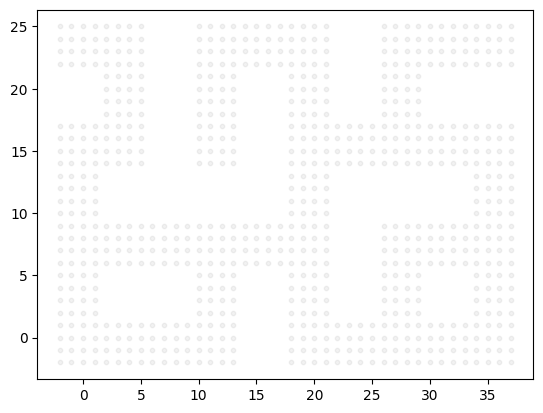

In [8]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c='gray', alpha=0.1, s=10)
plt.show()

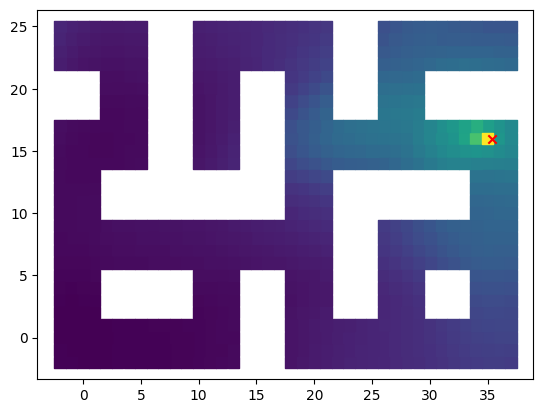

In [9]:
default_obs = train_dataset.dataset['observations'][np.random.randint(0, 100000)]
all_cell_obs = np.repeat(default_obs[None], len(all_cell_points), axis=0)

for i in range(len(all_cell_points)):
    all_cell_obs[i, 0] = all_cell_points[i, 0]
    all_cell_obs[i, 1] = all_cell_points[i, 1]

goal = train_dataset.dataset['observations'][np.random.randint(0, 100000), :2]
all_goals = np.repeat(goal[None], len(all_cell_points), axis=0)

vs = agent.network.select('value')(observations=all_cell_obs, goals=all_goals)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c=vs, cmap='viridis', alpha=1.0, s=68, marker='s')
plt.scatter(x=goal[0], y=goal[1], c='red', marker='x')
plt.show()

## Checking Subgoal Proposal

In [10]:
import jax

rng = jax.random.PRNGKey(saved_flags['seed'])

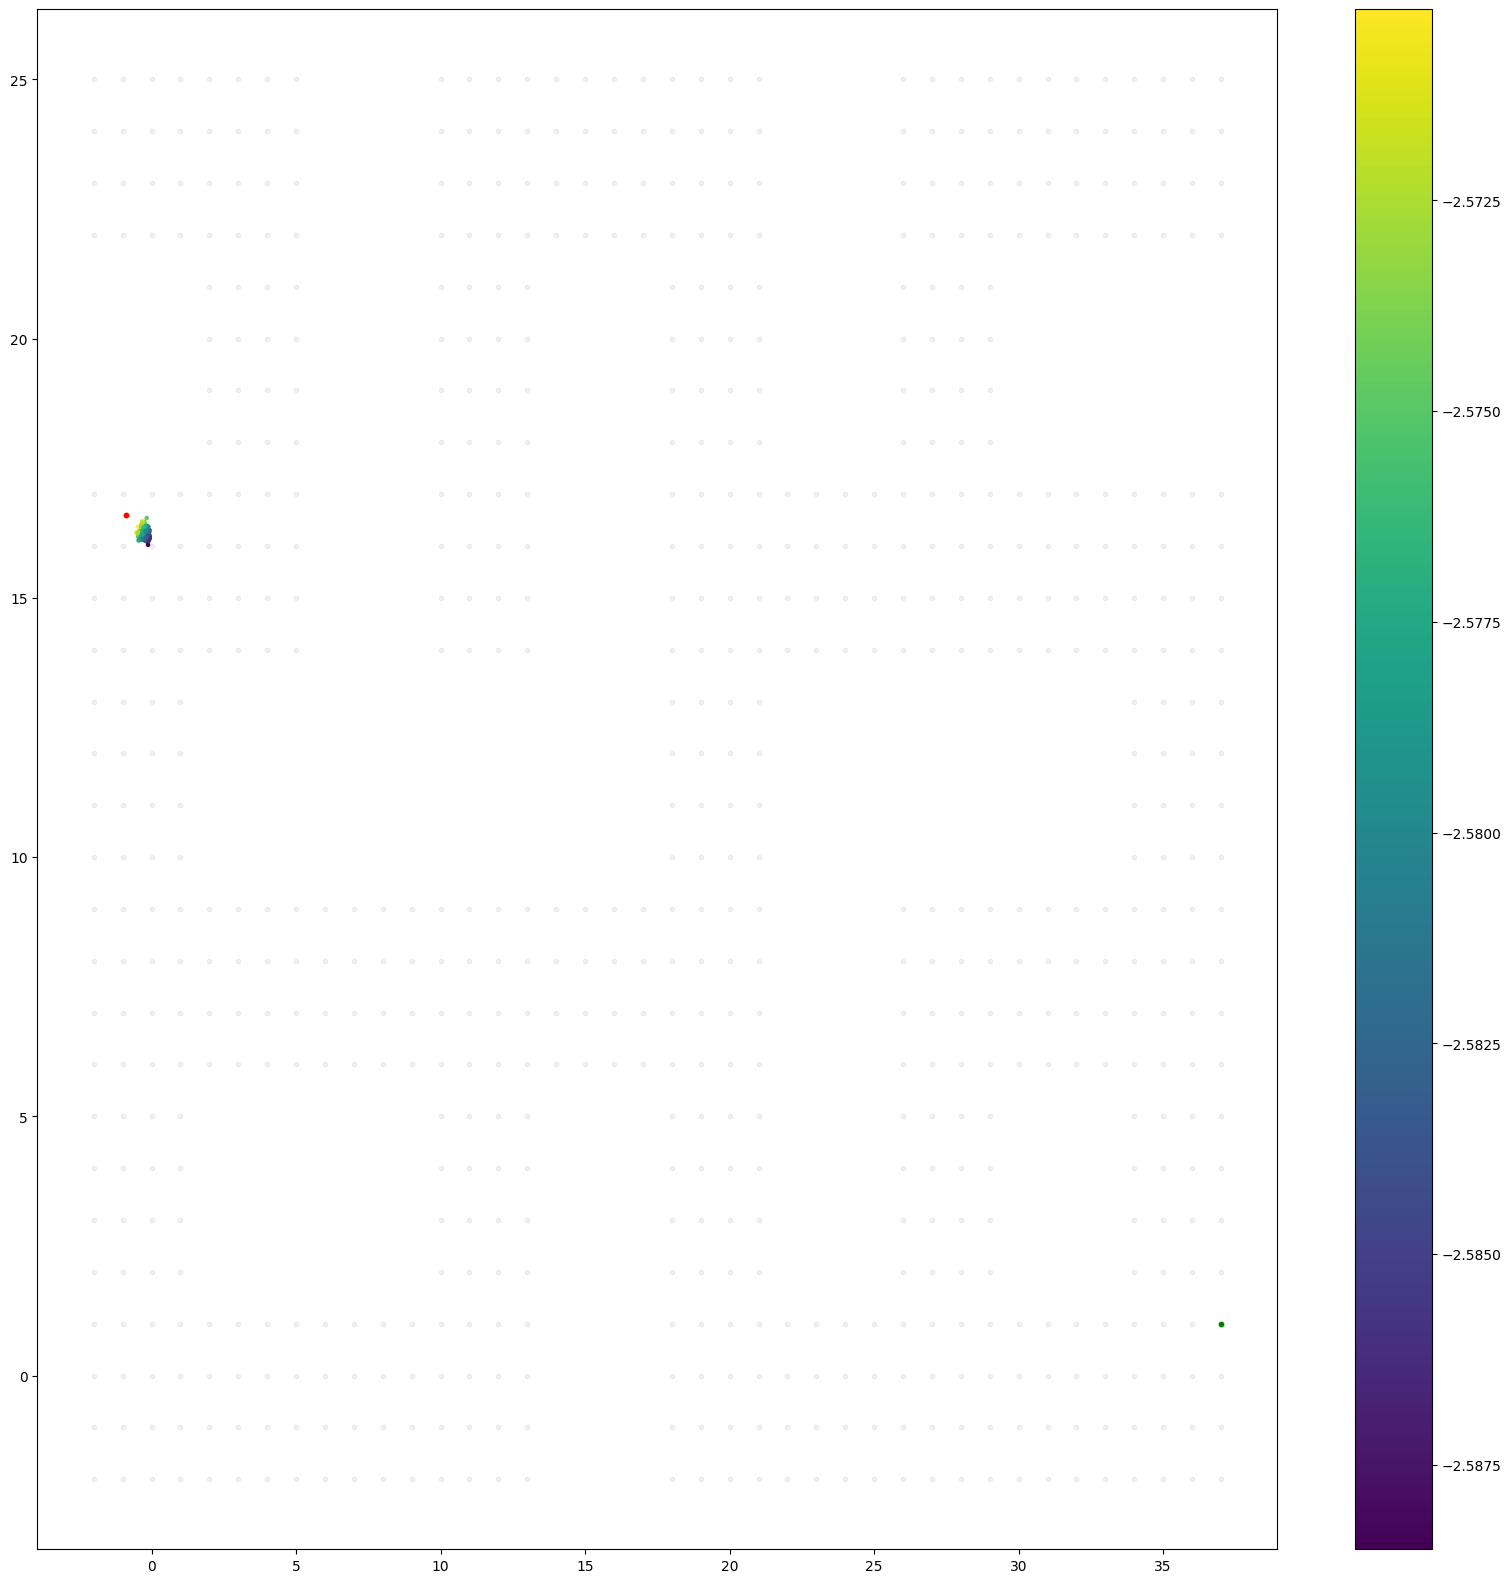

In [11]:
observation = default_obs
# goal = train_dataset.dataset['observations'][np.random.randint(100)][:2]
goal = np.asarray([37, 1])

rng, subgoal_rng = jax.random.split(rng)
subgoals = agent.propose_goals(observations=np.repeat(observation[None], 128, axis=0), goals=np.repeat(goal[None], 128, axis=0), rng=rng)

subgoal_obs = np.repeat(observation[None], 128, axis=0).copy()
for i in range(len(subgoals)):
    subgoal_obs[i, 0] = subgoals[i, 0]
    subgoal_obs[i, 1] = subgoals[i, 1]

vs = agent.network.select('value')(observations=subgoal_obs, goals=np.repeat(goal[None], 128, axis=0))

plt.figure(figsize=(20, 20))
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c='gray', alpha=0.1, s=10)
plt.scatter(x=default_obs[0], y=default_obs[1], c='red', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', s=10)
b = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], c=vs, cmap='viridis', s=5)
plt.colorbar(b)
plt.show()

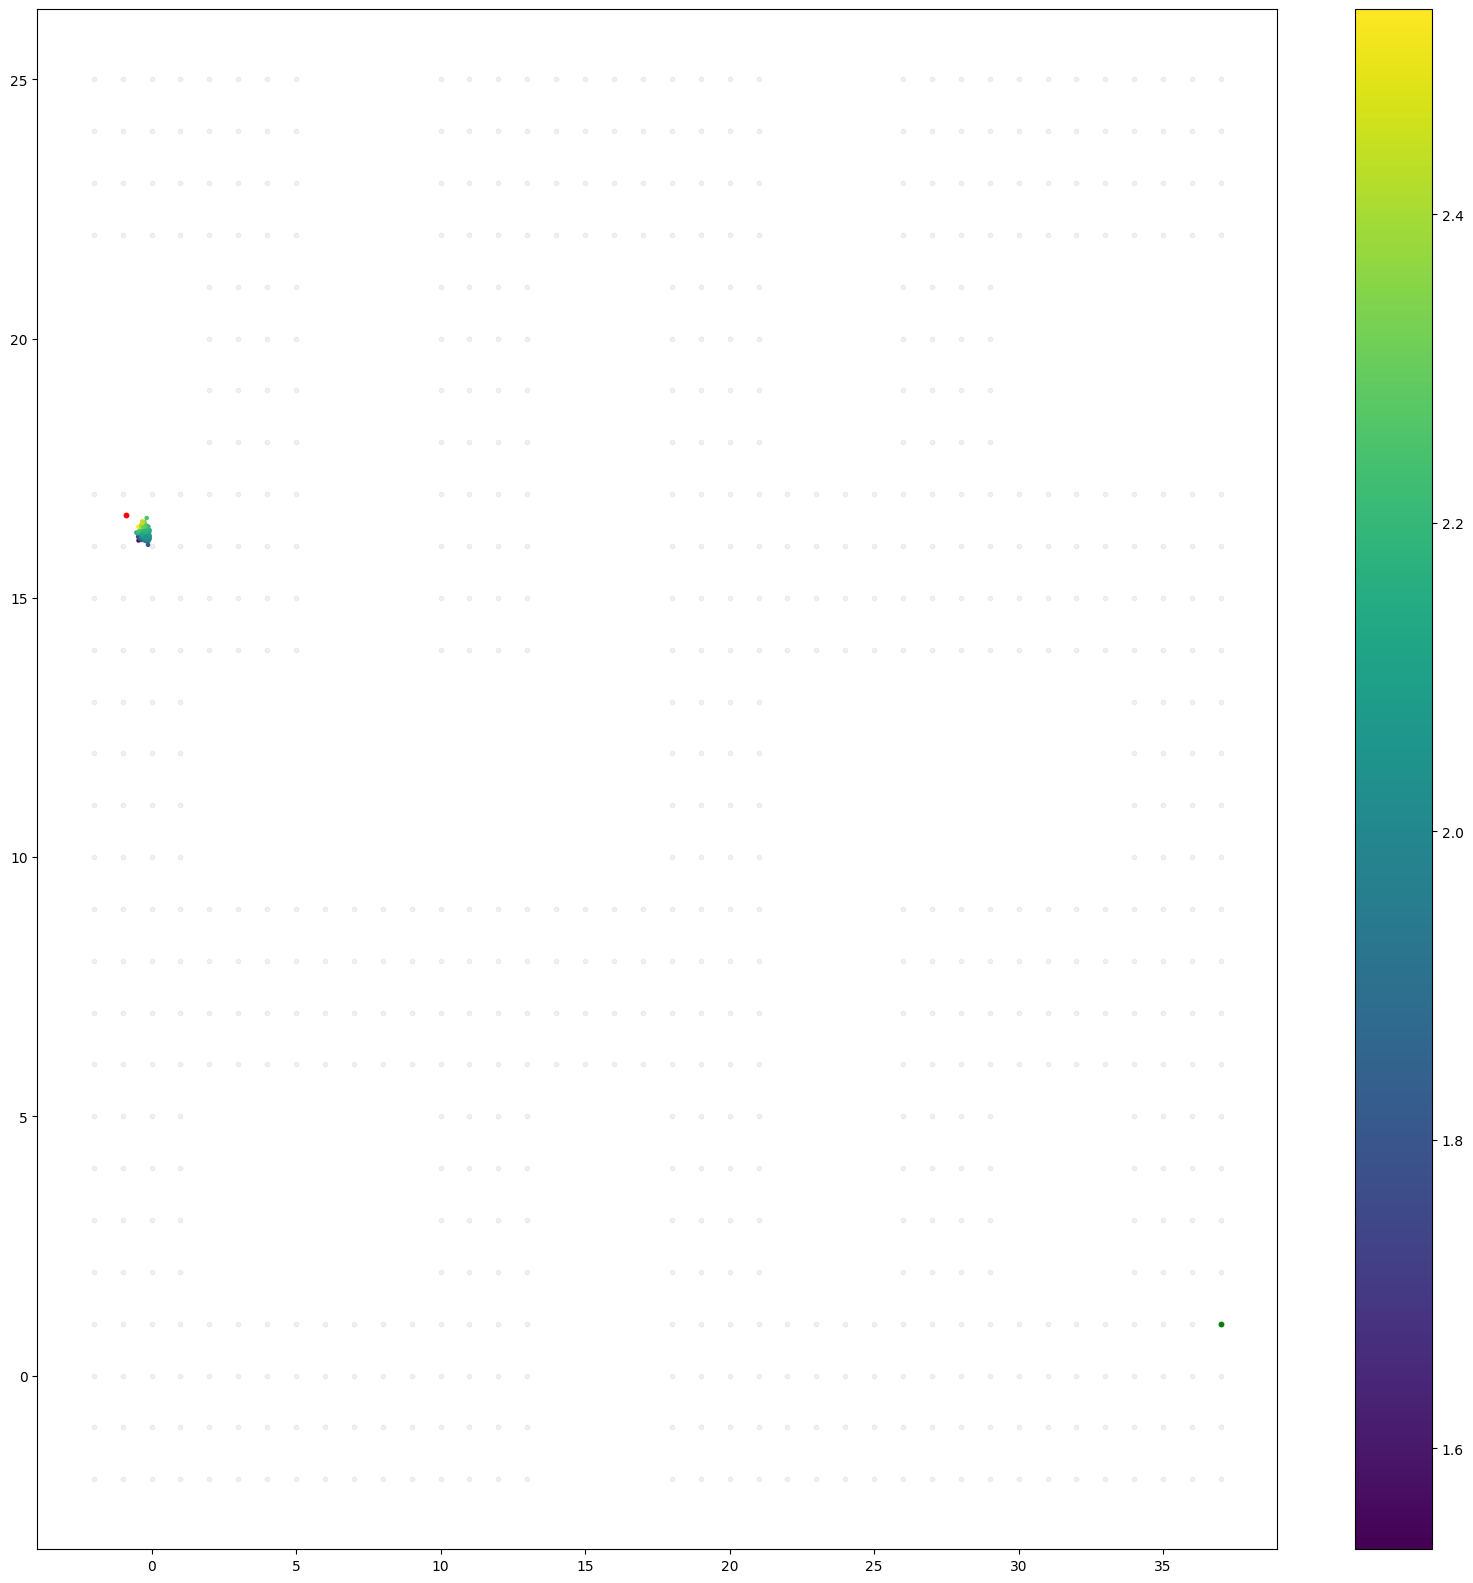

In [12]:
vs = agent.network.select('value')(observations=np.repeat(observation[None], 128, axis=0), goals=subgoals)

plt.figure(figsize=(20, 20))
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c='gray', alpha=0.1, s=10)
plt.scatter(x=default_obs[0], y=default_obs[1], c='red', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', s=10)
b = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], c=vs, cmap='viridis', s=5)
plt.colorbar(b)
plt.show()

## Check: is it goal-conditioned?

[15.150029 20.014717]
[15.135979 20.029272]
[15.19474  20.032072]
[15.272433 19.961086]
[15.316744 19.96409 ]
[15.359318 19.876657]
[15.504929 19.867437]
[15.611275 19.76524 ]
[15.688981 19.595762]
[15.771447 19.618008]
[15.9046335 19.625185 ]
[16.033134 19.515282]
[16.147604 19.495096]
[16.217903 19.4188  ]
[16.268074 19.3643  ]
[16.411503 19.365225]
[16.553492 19.331108]
[16.709908 19.325901]
[16.931505 19.218555]
[16.986532 19.142452]
[17.066568 19.099169]
[17.115314 19.030287]
[17.265017 19.02434 ]
[17.479488 18.968441]
[17.500624 18.87613 ]
[17.51824  18.830988]
[17.647469 18.759552]
[17.828703 18.682617]
[17.972986 18.629534]
[18.152851 18.589851]
[18.23994  18.552246]
[18.253418 18.38424 ]
[18.274166 18.156338]
[18.377615 18.075434]
[18.475819 17.81018 ]
[18.629284 17.63567 ]
[18.623423 17.541727]
[18.702522 17.488583]
[18.722925 17.3956  ]
[18.731834 17.33949 ]
[18.763393 17.282356]
[18.801079 17.249634]
[18.808228 17.180798]
[18.806795 17.08705 ]
[18.867086 17.075617]
[18.9047

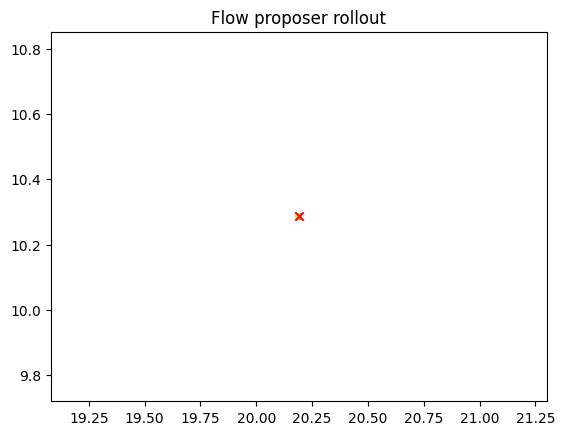

In [13]:
replay_buffer = []


# ob = np.asarray([15.0, 20.0])
ob = train_dataset.dataset['observations'][1000].copy()
ob[0] = 15.0
ob[1] = 20.0
goal = np.asarray([20.0, 0.0])
rng = jax.random.PRNGKey(saved_flags['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(agent.propose_goals(ob, goal, sample_rng))
    print(subgoal)

    if np.linalg.norm(subgoal - ob[:2]) < 0.0025:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        # ob = subgoal
        ob[0] = subgoal[0].copy()
        ob[1] = subgoal[1].copy()

replay_buffer = np.asarray(replay_buffer)
# plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
# plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [14]:
print(len(replay_buffer))
print(replay_buffer)

200
[[2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]
 [2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]
 [2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]
 ...
 [2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]
 [2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]
 [2.0189306e+01 1.0286000e+01 5.7140136e-01 ... 7.6183788e-03
  7.4570957e-03 1.3012360e-03]]


## Filtering by Value

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:11<00:00, 18.10it/s]


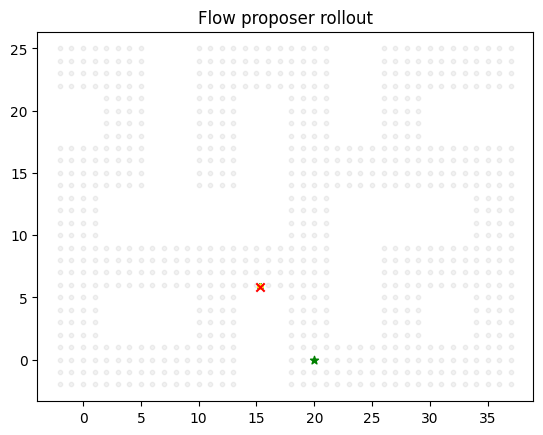

In [15]:
replay_buffer = []


# ob = np.asarray([15.0, 20.0])
ob = train_dataset.dataset['observations'][1000].copy()
ob[0] = 15.0
ob[1] = 20.0
goal = np.asarray([20.0, 0.0])
rng = jax.random.PRNGKey(saved_flags['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    
    subgoals = np.asarray(agent.propose_goals(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))
    # print(subgoal)

    subgoal_obs = np.repeat(ob[None], 128, axis=0)
    subgoal_obs[:, :2] = subgoals.copy()
    vs = agent.network.select('value')(subgoal_obs, np.repeat(goal[None], 128, axis=0))
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - ob[:2]) < 0.0025:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        # ob = subgoal
        ob[0] = subgoal[0].copy()
        ob[1] = subgoal[1].copy()

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [16]:
type(train_dataset)

utils.datasets.CGCDataset

In [17]:
# batch = train_dataset.dataset.sample_sequence(batch_size=1, sequence_length=1, discount=0.995)
# print(batch['low_actor_goals'])

## Using the flow network instead

In [18]:
saved_flags['env_name']

'humanoidmaze-large-navigate-singletask-task5-v0'

In [19]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=10000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=True,
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 10000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10,
 'backup_horizon': 25,
 'goal_conditioned': True}

In [20]:
from wrappers.datafuncs_utils import make_env_and_datasets

env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = CGCDataset(base_train_dataset, config=config)

In [21]:
from utils.networks import ActorVectorField

In [22]:
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


In [23]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']] if self.config['goal_conditioned'] else None
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if not self.config['goal_conditioned']:
            goals = None
        if single_example:
            observations = observations[None, ...]
            if goals is not None:
                goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        config = dict(config)
        config.setdefault('goal_conditioned', True)
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        init_goals = example_batch[config['goal_key']] if config['goal_conditioned'] else None
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=init_goals,
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [24]:
example_batch = train_dataset.sample(1)

In [25]:
example_batch.keys()

dict_keys(['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals', 'high_value_reps', 'high_value_goals', 'high_value_next_observations', 'high_value_offsets', 'valids', 'high_value_action_chunks', 'high_value_backup_horizon', 'high_value_masks', 'high_value_rewards', 'masks', 'rewards', 'actor_goals', 'low_actor_goals'])

In [26]:
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

{'mlp': {'Dense_0': {'bias': (256,), 'kernel': (7, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_3': {'bias': (2,), 'kernel': (256, 2)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [33]:
flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )


step=00001 flow_loss=1.211769 velocity_mae=0.863197
step=00100 flow_loss=1.233226 velocity_mae=0.875657
step=00200 flow_loss=1.281145 velocity_mae=0.879019
step=00300 flow_loss=1.106654 velocity_mae=0.817456
step=00400 flow_loss=1.263042 velocity_mae=0.867779
step=00500 flow_loss=1.363569 velocity_mae=0.889008
step=00600 flow_loss=1.483030 velocity_mae=0.938099
step=00700 flow_loss=1.303213 velocity_mae=0.908584
step=00800 flow_loss=1.216373 velocity_mae=0.867785
step=00900 flow_loss=1.242517 velocity_mae=0.882590
step=01000 flow_loss=1.211071 velocity_mae=0.854093
step=01100 flow_loss=1.228059 velocity_mae=0.855212
step=01200 flow_loss=1.162029 velocity_mae=0.838179
step=01300 flow_loss=1.347793 velocity_mae=0.891447
step=01400 flow_loss=1.153718 velocity_mae=0.858980
step=01500 flow_loss=1.229954 velocity_mae=0.872453
step=01600 flow_loss=1.223871 velocity_mae=0.882540
step=01700 flow_loss=1.214909 velocity_mae=0.853117
step=01800 flow_loss=1.180693 velocity_mae=0.850095
step=01900 f

100%|██████████| 200/200 [00:00<00:00, 1062.05it/s]


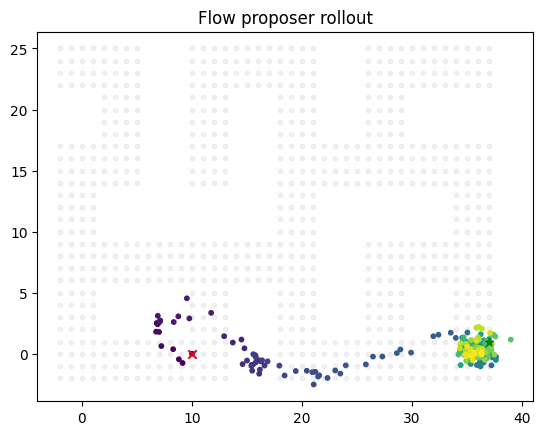

In [49]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([37, 1])
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## Training a non- goal-conditioned goal proposer

In [105]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=100000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=False,
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 100000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10,
 'backup_horizon': 25,
 'goal_conditioned': False}

In [106]:
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )


step=00001 flow_loss=309.477417 velocity_mae=14.742638
step=00100 flow_loss=35.779274 velocity_mae=4.432793
step=00200 flow_loss=20.965824 velocity_mae=3.422375
step=00300 flow_loss=5.759045 velocity_mae=1.757156
step=00400 flow_loss=3.564808 velocity_mae=1.440284
step=00500 flow_loss=2.867314 velocity_mae=1.348092
step=00600 flow_loss=2.939538 velocity_mae=1.320640
step=00700 flow_loss=2.659697 velocity_mae=1.276050
step=00800 flow_loss=2.948215 velocity_mae=1.342098
step=00900 flow_loss=2.319805 velocity_mae=1.219070
step=01000 flow_loss=2.021425 velocity_mae=1.141394
step=01100 flow_loss=1.834004 velocity_mae=1.092264
step=01200 flow_loss=2.143398 velocity_mae=1.162268
step=01300 flow_loss=2.248317 velocity_mae=1.219272
step=01400 flow_loss=2.052389 velocity_mae=1.134039
step=01500 flow_loss=2.075357 velocity_mae=1.120199
step=01600 flow_loss=1.969640 velocity_mae=1.086296
step=01700 flow_loss=1.810685 velocity_mae=1.063448
step=01800 flow_loss=2.036084 velocity_mae=1.124623
step=01

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 107.70it/s]


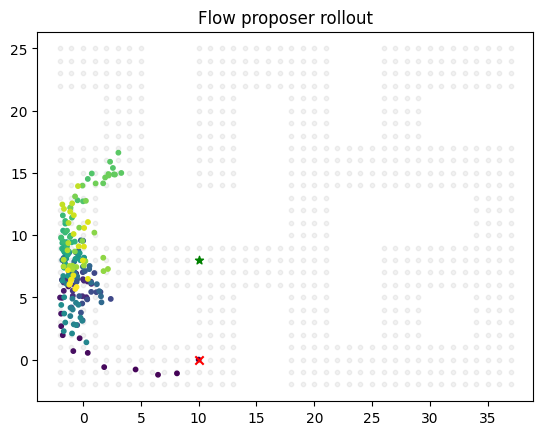

In [107]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([10.0, 8.0])
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

Okay, confirmed that this doesn't seem goal-conditioned!

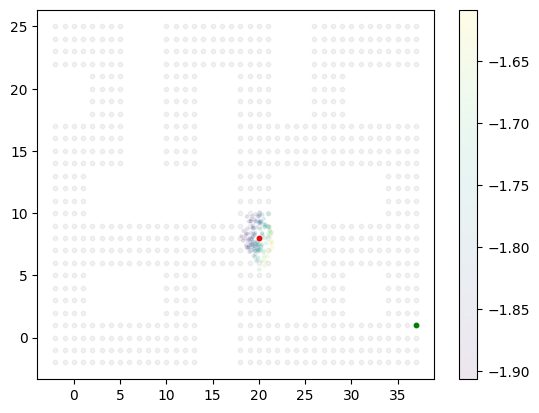

In [108]:
# observation = default_obs
default_obs = train_dataset.dataset['observations'][np.random.randint(100)]
start = np.asarray([20.0, 08.0])
goal = np.asarray([37, 1])

ob = start.copy()

rng, subgoal_rng = jax.random.split(rng)
subgoals = flow_agent.sample_actions(observations=np.repeat(ob[None], 128, axis=0), goals=np.repeat(goal[None], 128, axis=0), rng=rng)
# np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

subgoal_obs = np.repeat(default_obs[None], 128, axis=0).copy()
for i in range(len(subgoals)):
    subgoal_obs[i, 0] = subgoals[i, 0]
    subgoal_obs[i, 1] = subgoals[i, 1]

vs = agent.network.select('value')(observations=subgoal_obs, goals=np.repeat(goal[None], 128, axis=0))

# plt.figure(figsize=(20, 20))
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c='gray', alpha=0.1, s=10)
plt.scatter(x=start[0], y=start[1], c='red', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', s=10)
b = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], c=vs, cmap='viridis', s=5, alpha=0.1)
plt.colorbar(b)
plt.show()

It's no longer unimodal!

100%|██████████| 1000000/1000000 [00:03<00:00, 262420.62it/s]


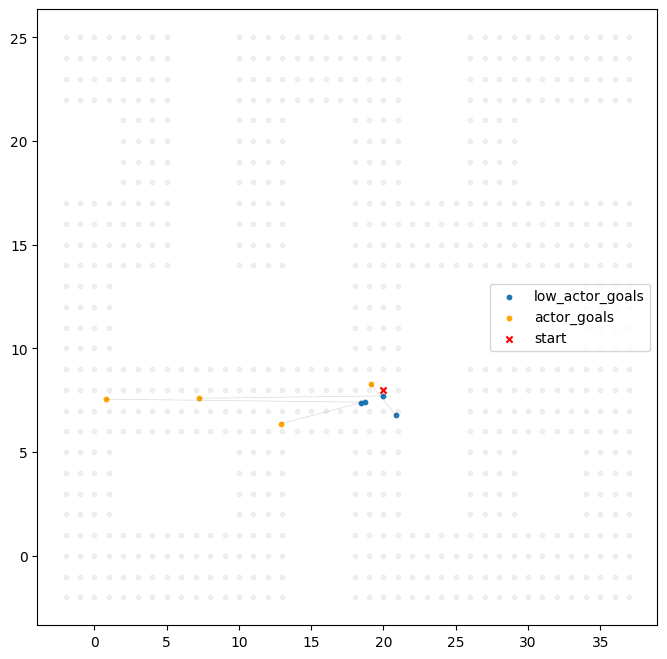

In [109]:
r = 1000000
low_actor_goals = []
actor_goals = []
samples = train_dataset.sample(batch_size=r, idxs=np.arange(r))

for i in tqdm(range(r)):
    sample_ob = samples['observations'][i]
    
    if np.linalg.norm(sample_ob[:2] - start) < 0.02:
        low_actor_goals.append(samples['low_actor_goals'][i])
        actor_goals.append(samples['actor_goals'][i])

low_actor_goals = np.asarray(low_actor_goals)
actor_goals = np.asarray(actor_goals)

if len(low_actor_goals) > 0:
    plt.figure(figsize=(8, 8))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c='gray', alpha=0.1, s=10)
    
    for i in range(len(low_actor_goals)):
        plt.plot(
            [low_actor_goals[i, 0], actor_goals[i, 0]],
            [low_actor_goals[i, 1], actor_goals[i, 1]],
            c='black',
            alpha=0.15,
            linewidth=0.5,
        )
    
    plt.scatter(x=low_actor_goals[..., 0], y=low_actor_goals[..., 1], s=10, label='low_actor_goals')
    plt.scatter(x=actor_goals[..., 0], y=actor_goals[..., 1], s=10, c='orange', label='actor_goals')
    plt.scatter(x=start[0], y=start[1], s=20, marker='x', c='red', label='start')
    plt.legend()
    plt.show()
else:
    print('not enough')


### Only argmax values

 74%|███████▎  | 147/200 [00:07<00:02, 20.66it/s]


reached at step 147!
subgoal: [36.996517   1.0017183]


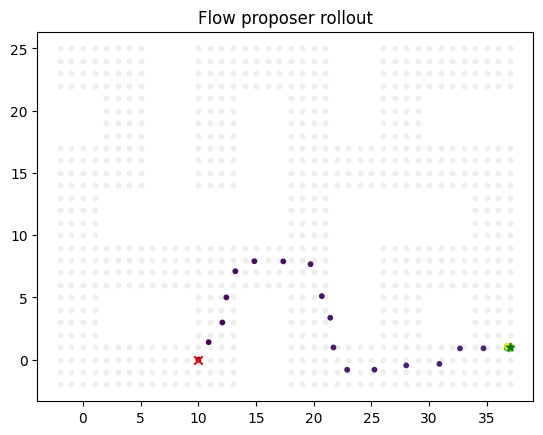

In [110]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([37, 1])
rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals
    vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

 74%|███████▎  | 147/200 [00:05<00:02, 26.07it/s]


reached at step 147!
subgoal: [36.996517  1.001717]


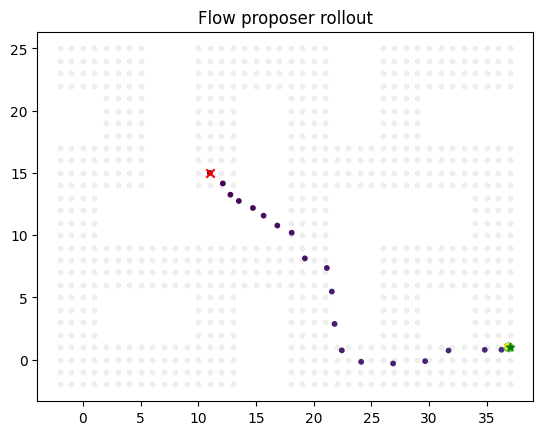

In [111]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([37, 1])
rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals
    vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

### Argmax sum of values

 22%|██▏       | 43/200 [00:03<00:12, 12.56it/s]

reached at step 43!
subgoal: [37.001957   1.0001451]


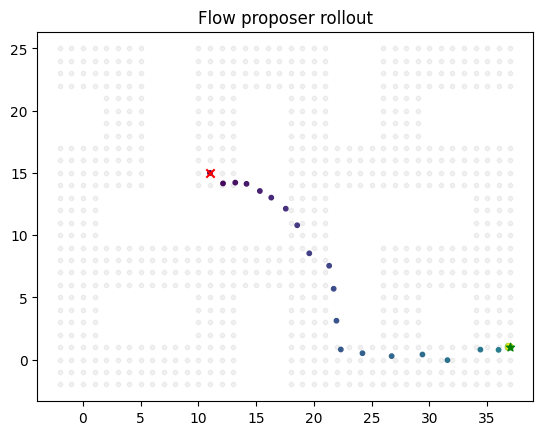

In [112]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([37, 1])
rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

 22%|██▏       | 43/200 [00:03<00:12, 12.99it/s]


reached at step 43!
subgoal: [37.001957   1.0001259]


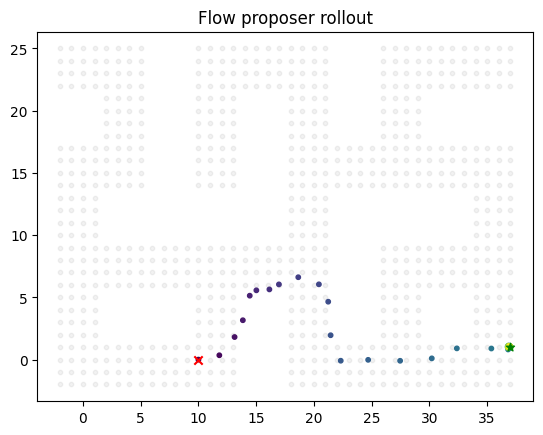

In [113]:
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([37, 1])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

100%|██████████| 200/200 [00:16<00:00, 12.32it/s]


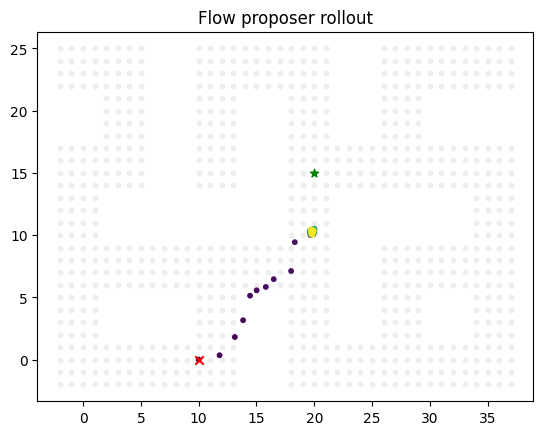

In [ ]:
ob = np.asarray([10.0, 0.0])
# ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 15.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

**Failure mode:** there can also be fixed points.

  6%|▋         | 13/200 [00:01<00:15, 12.10it/s]


reached at step 13!
subgoal: [19.979904 15.022755]


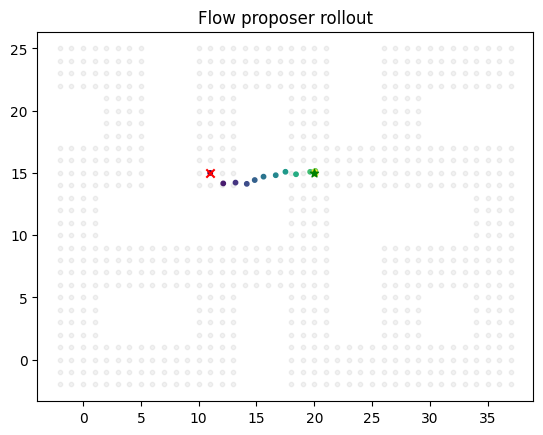

In [115]:
# ob = np.asarray([10.0, 0.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 15.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [116]:
class GCMLPPolicy(nn.Module):
    hidden_dims: tuple[int, ...]
    action_dim: int
    layer_norm: bool = True

    @nn.compact
    def __call__(self, observations, goals):
        x = jnp.concatenate([observations, goals], axis=-1)
        x = MLP(self.hidden_dims, activate_final=True, layer_norm=self.layer_norm)(x)
        x = nn.Dense(self.action_dim)(x)
        return x


class GCILAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def actor_loss(self, batch, grad_params=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        pred_actions = self.network(observations, goals, params=grad_params)
        target_actions = batch[self.config['actions_key']]
        loss = jnp.mean(jnp.square(pred_actions - target_actions))
        mae = jnp.mean(jnp.abs(pred_actions - target_actions))
        return loss, {
            'loss': loss,
            'mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.actor_loss(batch, grad_params)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals):
        return self.network(observations, goals)

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = GCMLPPolicy(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            example_batch[config['goal_key']],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))


  0%|          | 51/100000 [00:02<59:00, 28.23it/s]  

step=00001 loss=334.777771 mae=15.397907


  0%|          | 204/100000 [00:02<10:40, 155.92it/s]

step=00100 loss=39.925308 mae=4.705485
step=00200 loss=25.311611 mae=3.816967


  0%|          | 366/100000 [00:03<05:10, 321.04it/s]

...

step=99500 loss=0.378625 mae=0.457018
step=99600 loss=0.380597 mae=0.449586


100%|█████████▉| 99754/100000 [03:15<00:00, 524.57it/s]

step=99700 loss=0.418298 mae=0.487712
step=99800 loss=0.393669 mae=0.468518


100%|██████████| 100000/100000 [03:15<00:00, 510.88it/s]

step=99900 loss=0.385002 mae=0.461999
step=100000 loss=0.379213 mae=0.468959


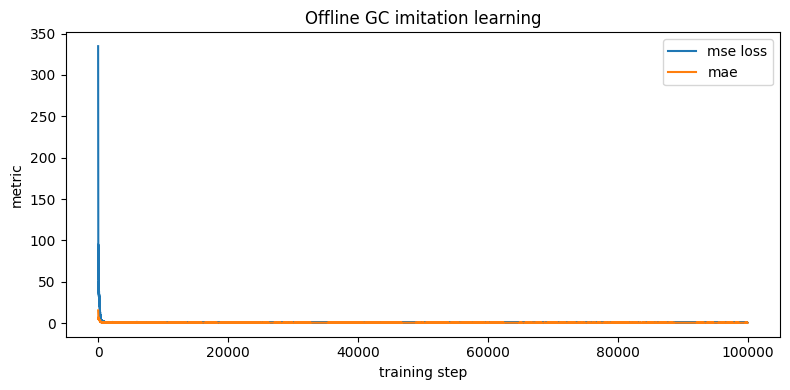

In [118]:
deterministic_agent = GCILAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, agent.network.params)

loss_history = []
mae_history = []

for step in tqdm(range(1, config['num_train_steps'] + 1)):
    batch = train_dataset.sample(config['batch_size'])
    deterministic_agent, info = deterministic_agent.update(batch)

    loss_history.append(float(info['loss']))
    mae_history.append(float(info['mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} loss={loss_history[-1]:.6f} mae={mae_history[-1]:.6f}"
        )

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='mse loss')
plt.plot(mae_history, label='mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Offline GC imitation learning')
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
eval_batch = train_dataset.sample(8)
pred_actions = np.asarray(
    deterministic_agent.sample_actions(
        eval_batch[config['observations_key']],
        eval_batch[config['goal_key']],
    )
)
target_actions = np.asarray(eval_batch[config['actions_key']])

print('predicted actions shape:', pred_actions.shape)
print('target actions shape:', target_actions.shape)
print('sample mse:', np.mean((pred_actions - target_actions) ** 2))

predicted actions shape: (8, 2)
target actions shape: (8, 2)
sample mse: 0.49382332


100%|██████████| 200/200 [00:00<00:00, 2452.73it/s]


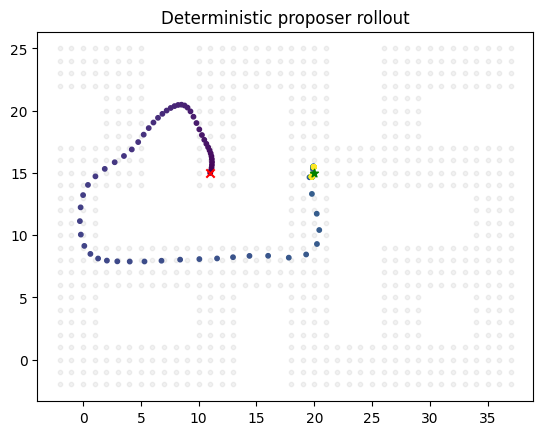

In [122]:
# ob = np.asarray([10.0, 0.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 15.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    # rng, sample_rng = jax.random.split(rng)
    # subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    # subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    # subgoals_obs[..., :2] = subgoals

    # ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    # subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    # vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    # idx = np.argmax(vs)
    # subgoal = subgoals[idx]
    subgoal = deterministic_agent.sample_actions(ob, goal)

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Deterministic proposer rollout')
plt.show()

 36%|███▌      | 71/200 [00:00<00:00, 1586.72it/s]

reached at step 71!
subgoal: [36.96261     0.97158515]


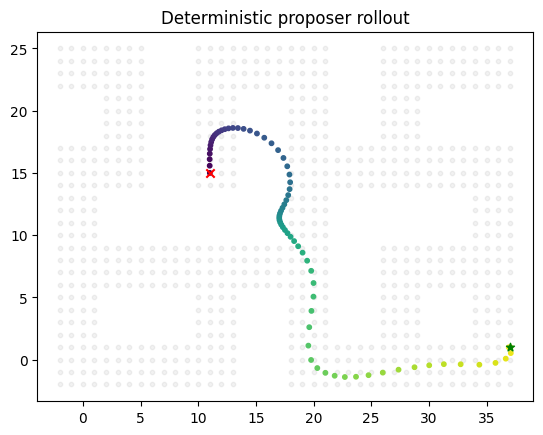

In [123]:
# ob = np.asarray([10.0, 0.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([37.0, 1.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    # rng, sample_rng = jax.random.split(rng)
    # subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    # subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    # subgoals_obs[..., :2] = subgoals

    # ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    # subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    # vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    # idx = np.argmax(vs)
    # subgoal = subgoals[idx]
    subgoal = deterministic_agent.sample_actions(ob, goal)

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Deterministic proposer rollout')
plt.show()

100%|██████████| 200/200 [00:00<00:00, 2038.12it/s]


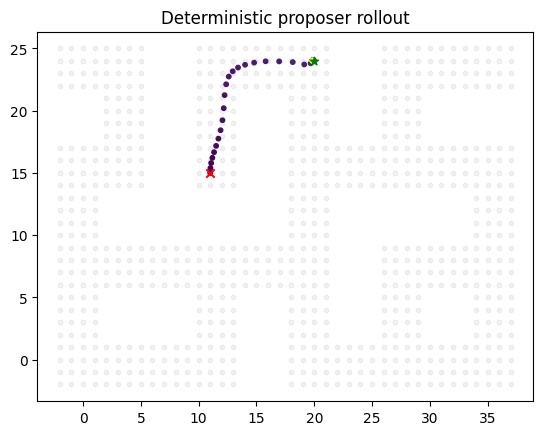

In [124]:
# ob = np.asarray([10.0, 0.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 24.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    # rng, sample_rng = jax.random.split(rng)
    # subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    # subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    # subgoals_obs[..., :2] = subgoals

    # ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    # subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    # vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    
    # idx = np.argmax(vs)
    # subgoal = subgoals[idx]
    subgoal = deterministic_agent.sample_actions(ob, goal)

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Deterministic proposer rollout')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

  4%|▎         | 7/200 [00:00<00:09, 21.19it/s]


reached at step 7!
subgoal: [19.995079 23.976824]


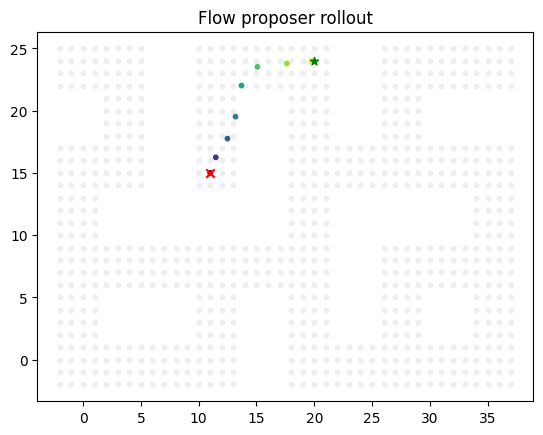

In [126]:
# ob = np.asarray([10.0, 0.0])
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 24.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    # ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    # vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    vs = subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

100%|██████████| 200/200 [00:00<00:00, 2261.92it/s]


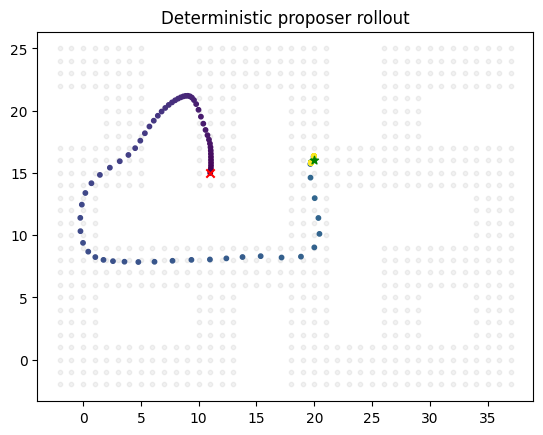

In [127]:
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 16.0])

replay_buffer = []
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    subgoal = deterministic_agent.sample_actions(ob, goal)

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Deterministic proposer rollout')
plt.show()

 12%|█▏        | 24/200 [00:00<00:07, 25.02it/s]


reached at step 24!
subgoal: [20.017365 15.99846 ]


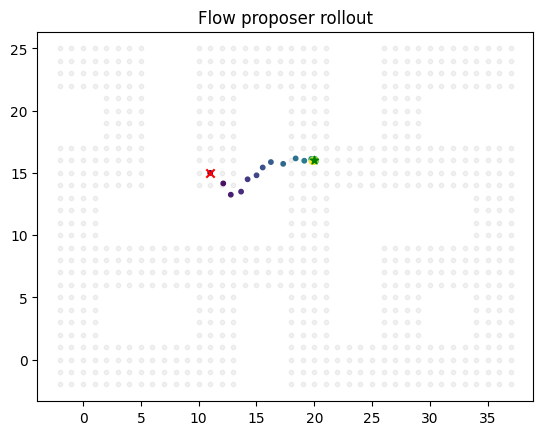

In [ ]:
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 16.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    # ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    # vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    vs = subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

  6%|▌         | 12/200 [00:00<00:15, 12.44it/s]

reached at step 12!
subgoal: [20.041023 16.016293]


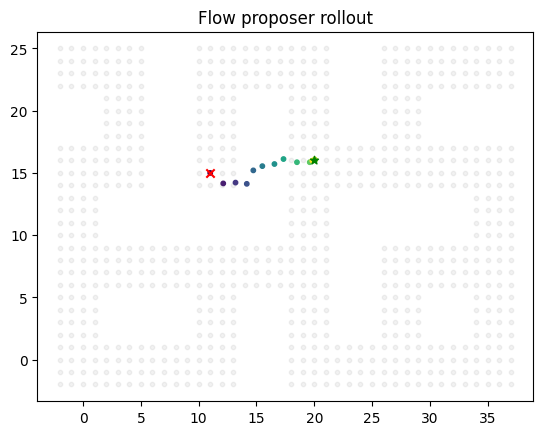

In [129]:
ob = np.asarray([11.0, 15.0])
goal = np.asarray([20.0, 16.0])

replay_buffer = []

rng = jax.random.PRNGKey(config['seed'])

# default_obs = 

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(flow_agent.sample_actions(np.repeat(ob[None], 128, axis=0), np.repeat(goal[None], 128, axis=0), sample_rng))

    subgoals_obs = np.repeat(default_obs[None], 128, axis=0)
    subgoals_obs[..., :2] = subgoals

    ob_to_subgoal_vs = agent.network.select('value')(np.repeat(ob[None], 128, axis=0), subgoals_obs)
    subgoal_to_goal_vs = agent.network.select('value')(subgoals_obs, np.repeat(goal[None], 128, axis=0))

    vs = ob_to_subgoal_vs + subgoal_to_goal_vs
    # vs = subgoal_to_goal_vs
    
    idx = np.argmax(vs)
    subgoal = subgoals[idx]

    if np.linalg.norm(subgoal - goal) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

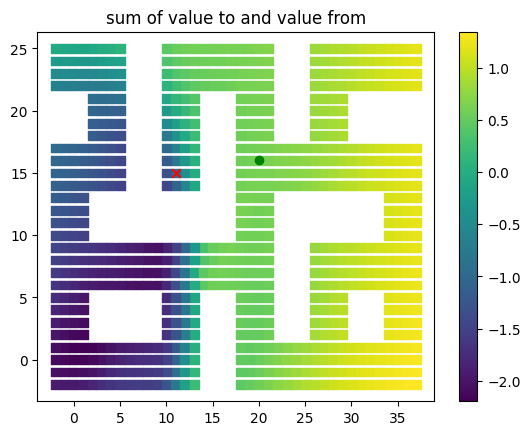

In [151]:
end = np.asarray([20.0, 16.0])
start = np.asarray([11.0, 15.0])

subgoal_to_goal = agent.network.select('value')(observations=all_cell_obs, goals=np.repeat(end[None], len(all_cell_obs), axis=0))

ob_to_subgoal = agent.network.select('value')(observations=np.repeat(start[None], len(all_cell_obs), axis=0), goals=all_cell_obs)

# vs = np.log(subgoal_to_goal + ob_to_subgoal + 10.0)
# vs = subgoal_to_goal + ob_to_subgoal
vs = ob_to_subgoal

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], c=vs, cmap='viridis', alpha=1.0, s=40, marker='s')
plt.scatter(x=start[0], y=start[1], c='red', marker='x')
plt.scatter(x=end[0], y=end[1], c='green')
plt.title('sum of value to and value from')
plt.colorbar(c)
plt.show()